In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Confirm everything loaded
print("All imports successful")
print(f"pandas: {pd.__version__}")
print(f"yfinance: {yf.__version__}")

All imports successful
pandas: 2.3.3
yfinance: 1.4.1


In [2]:
# Load MPC decisions
mpc_df = pd.read_csv('../data/rbi_mpc_decisions.csv')
mpc_df['Date'] = pd.to_datetime(mpc_df['Date'], dayfirst=True)

# Verify
print(f"Shape: {mpc_df.shape}")
print(f"\nFirst date: {mpc_df['Date'].iloc[0]}")  # Must show 2016-10-04, not 2016-04-10
print(f"Last date:  {mpc_df['Date'].iloc[-1]}")
print(f"\nDecision counts:\n{mpc_df['Decision'].value_counts()}")
print(f"\nRate change range: {mpc_df['Rate_Change_bps'].min()} to {mpc_df['Rate_Change_bps'].max()} bps")

Shape: (52, 4)

First date: 2016-10-04 00:00:00
Last date:  2025-02-07 00:00:00

Decision counts:
Decision
Hold    34
Cut     10
Hike     8
Name: count, dtype: int64

Rate change range: -75 to 50 bps


In [3]:
# Download Nifty 50
print("Downloading Nifty 50 data...")
nifty_raw = yf.download('^NSEI', start='2015-01-01', end='2025-12-31', progress=False)

# yfinance sometimes returns MultiIndex columns - flatten if needed
if isinstance(nifty_raw.columns, pd.MultiIndex):
    nifty_raw.columns = nifty_raw.columns.get_level_values(0)

# Calculate daily returns
nifty_raw['Return'] = nifty_raw['Close'].pct_change() * 100

# Verify
print(f"Shape: {nifty_raw.shape}")
print(f"Date range: {nifty_raw.index[0].date()} to {nifty_raw.index[-1].date()}")
print(f"Missing returns: {nifty_raw['Return'].isna().sum()}")
print(f"\nSample (first 3 rows):")
print(nifty_raw[['Close', 'Return']].head(3))

Shape: (2707, 6)
Date range: 2015-01-02 to 2025-12-30
Missing returns: 1

Sample (first 3 rows):
Price             Close    Return
Date                             
2015-01-02  8395.450195       NaN
2015-01-05  8378.400391 -0.203084
2015-01-06  8127.350098 -2.996399


In [4]:
# Make a clean return series
nifty_returns = nifty_raw['Return'].copy()

# Strip timezone if present (prevents silent NaN on all merges)
if nifty_returns.index.tz is not None:
    nifty_returns.index = nifty_returns.index.tz_localize(None)

# Normalize to midnight to ensure date-only matching
nifty_returns.index = nifty_returns.index.normalize()

# Map each MPC date to its Nifty return
mpc_df['Nifty_Return'] = mpc_df['Date'].map(nifty_returns)

# Diagnosis
matched = mpc_df['Nifty_Return'].notna().sum()
print(f"Matched: {matched} / {len(mpc_df)} MPC dates")
print(f"Unmatched: {mpc_df['Nifty_Return'].isna().sum()}")

# Show any unmatched dates - these are likely holidays or off-cycle meetings
if mpc_df['Nifty_Return'].isna().any():
    print("\nUnmatched dates:")
    print(mpc_df[mpc_df['Nifty_Return'].isna()][['Date', 'Decision', 'Rate_Change_bps']])

Matched: 52 / 52 MPC dates
Unmatched: 0


In [5]:
# Basic summary: raw returns by decision type
summary = mpc_df.groupby('Decision')['Nifty_Return'].agg(['mean', 'median', 'std', 'count'])
summary.columns = ['Mean_Return', 'Median_Return', 'Std_Dev', 'Count']
summary = summary.round(4)

# Normal day baseline for comparison
normal_mean = nifty_raw['Return'].mean()
normal_std = nifty_raw['Return'].std()

print("=== Average Nifty Returns on MPC Days ===")
print(summary)
print(f"\nNormal day average (all 2707 days): {normal_mean:.4f}%")
print(f"Normal day std dev: {normal_std:.4f}%")

=== Average Nifty Returns on MPC Days ===
          Mean_Return  Median_Return  Std_Dev  Count
Decision                                            
Cut           -0.4564        -0.3612   0.6106     10
Hike           0.0314        -0.0008   1.1808      8
Hold           0.1584         0.1003   0.8965     34

Normal day average (all 2707 days): 0.0470%
Normal day std dev: 1.0236%


In [6]:
def calculate_abnormal_return(date, returns, estimation_window=250, exclusion=30):
    """
    Abnormal return = actual return minus mean return 
    during estimation window (250 days before, excluding 30 days pre-event)
    """
    try:
        idx = returns.index.get_loc(date)
    except KeyError:
        return np.nan
    
    if idx < estimation_window:
        return np.nan
    
    estimation_returns = returns.iloc[idx - estimation_window : idx - exclusion]
    normal_return = estimation_returns.mean()
    actual_return = returns.iloc[idx]
    return actual_return - normal_return

# Apply to all MPC dates
nifty_returns_clean = nifty_raw['Return'].dropna()

mpc_df['Abnormal_Return'] = mpc_df['Date'].apply(
    lambda x: calculate_abnormal_return(x, nifty_returns_clean)
)

print(f"Abnormal returns calculated: {mpc_df['Abnormal_Return'].notna().sum()} / {len(mpc_df)}")
print(f"Dropped (insufficient history): {mpc_df['Abnormal_Return'].isna().sum()}")

# Summary by decision type
ab_summary = mpc_df.groupby('Decision')['Abnormal_Return'].agg(['mean', 'std', 'count']).round(4)
print(f"\n=== Abnormal Returns by Decision ===")
print(ab_summary)

Abnormal returns calculated: 52 / 52
Dropped (insufficient history): 0

=== Abnormal Returns by Decision ===
            mean     std  count
Decision                       
Cut      -0.4706  0.6054     10
Hike      0.0043  1.1938      8
Hold      0.0807  0.8934     34


In [7]:
from scipy import stats

print("=== Statistical Significance Tests ===\n")

decisions = ['Cut', 'Hike', 'Hold']

for decision in decisions:
    returns = mpc_df[mpc_df['Decision'] == decision]['Abnormal_Return'].dropna()
    t_stat, p_value = stats.ttest_1samp(returns, 0)
    sig = "SIGNIFICANT" if p_value < 0.05 else "not significant"
    print(f"{decision} (n={len(returns)}):")
    print(f"  Mean: {returns.mean():.4f}%  |  t={t_stat:.3f}  |  p={p_value:.3f}  |  {sig}")
    print()

# Overall test: are MPC days different from zero at all?
all_mpc = mpc_df['Abnormal_Return'].dropna()
t_all, p_all = stats.ttest_1samp(all_mpc, 0)
print(f"All MPC days combined (n={len(all_mpc)}):")
print(f"  Mean: {all_mpc.mean():.4f}%  |  t={t_all:.3f}  |  p={p_all:.3f}")

# Pre vs Post COVID
print("\n=== Pre-COVID vs Post-COVID ===")
pre = mpc_df[mpc_df['Date'] < '2020-01-01']['Abnormal_Return']
post = mpc_df[mpc_df['Date'] > '2021-06-01']['Abnormal_Return']
print(f"Pre-COVID mean: {pre.mean():.4f}%  (n={len(pre)})")
print(f"Post-COVID mean: {post.mean():.4f}%  (n={len(post)})")
t_split, p_split = stats.ttest_ind(pre.dropna(), post.dropna())
print(f"Difference significant? t={t_split:.3f}, p={p_split:.3f}")


=== Statistical Significance Tests ===

Cut (n=10):
  Mean: -0.4706%  |  t=-2.458  |  p=0.036  |  SIGNIFICANT

Hike (n=8):
  Mean: 0.0043%  |  t=0.010  |  p=0.992  |  not significant

Hold (n=34):
  Mean: 0.0807%  |  t=0.526  |  p=0.602  |  not significant

All MPC days combined (n=52):
  Mean: -0.0371%  |  t=-0.295  |  p=0.769

=== Pre-COVID vs Post-COVID ===
Pre-COVID mean: -0.3175%  (n=20)
Post-COVID mean: 0.0532%  (n=24)
Difference significant? t=-1.306, p=0.199


In [8]:
# Flag COVID emergency cuts (off-cycle, off-schedule meetings)
covid_cuts = ['2020-03-27', '2020-05-22']
mpc_df['Is_Emergency'] = mpc_df['Date'].isin(pd.to_datetime(covid_cuts))

# Rerun cut analysis excluding COVID emergency cuts
cuts_all = mpc_df[mpc_df['Decision'] == 'Cut']['Abnormal_Return']
cuts_excl_covid = mpc_df[
    (mpc_df['Decision'] == 'Cut') & 
    (~mpc_df['Is_Emergency'])
]['Abnormal_Return']

print("=== Cut Days: COVID Sensitivity Check ===")
print(f"\nAll cuts (n={len(cuts_all)}):")
t1, p1 = stats.ttest_1samp(cuts_all.dropna(), 0)
print(f"  Mean: {cuts_all.mean():.4f}%  |  t={t1:.3f}  |  p={p1:.3f}")

print(f"\nExcluding COVID emergency cuts (n={len(cuts_excl_covid)}):")
t2, p2 = stats.ttest_1samp(cuts_excl_covid.dropna(), 0)
print(f"  Mean: {cuts_excl_covid.mean():.4f}%  |  t={t2:.3f}  |  p={p2:.3f}")

print(f"\nCOVID emergency cuts only (n=2):")
covid_returns = mpc_df[mpc_df['Is_Emergency']]['Abnormal_Return']
print(f"  Returns: {covid_returns.values.round(4)}")
print(f"  Mean: {covid_returns.mean():.4f}%")

=== Cut Days: COVID Sensitivity Check ===

All cuts (n=10):
  Mean: -0.4706%  |  t=-2.458  |  p=0.036

Excluding COVID emergency cuts (n=8):
  Mean: -0.5358%  |  t=-2.390  |  p=0.048

COVID emergency cuts only (n=2):
  Returns: [ 0.187  -0.6067]
  Mean: -0.2099%


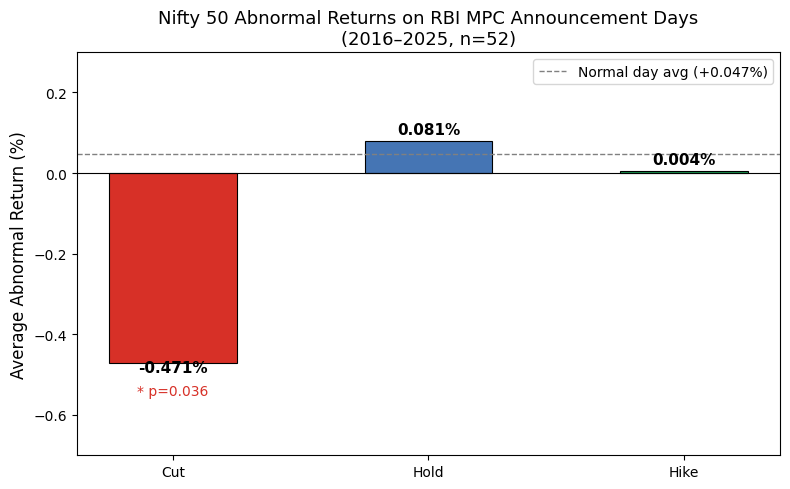

Chart 1 saved.


In [19]:
# Chart 1: Abnormal returns by decision type
fig, ax = plt.subplots(figsize=(8, 5))

decisions_order = ['Cut', 'Hold', 'Hike']
means = [mpc_df[mpc_df['Decision']==d]['Abnormal_Return'].mean() for d in decisions_order]
colors = ['#d73027', '#4575b4', '#1a9850']

bars = ax.bar(decisions_order, means, color=colors, width=0.5, edgecolor='black', linewidth=0.8)

# Add value labels on bars
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + (0.01 if val >= 0 else -0.03),
            f'{val:.3f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Reference line
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(nifty_raw['Return'].mean(), color='gray', linewidth=1, 
           linestyle='--', label=f'Normal day avg (+{nifty_raw["Return"].mean():.3f}%)')

ax.set_ylabel('Average Abnormal Return (%)', fontsize=12)
ax.set_title('Nifty 50 Abnormal Returns on RBI MPC Announcement Days\n(2016–2025, n=52)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(-0.7, 0.3)

# Significance annotation
ax.text(0, -0.55, '* p=0.036', ha='center', fontsize=10, color='#d73027')

plt.tight_layout()
plt.savefig('../outputs/figures/chart1_abnormal_returns_by_decision.png', dpi=150)
plt.show()
print("Chart 1 saved.")